# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 6: Evaluación del Desempeño del Modelo**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, recall_score, \
							precision_score, precision_recall_curve, roc_curve, auc
from sklearn.calibration import calibration_curve

import os
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from dateutil.relativedelta import relativedelta

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s06")

np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 🎯 **Objetivos de la sesión**

En Credit Scoring, evaluar un modelo no es solo medir accuracy.

Queremos responder 4 preguntas clave:
- **Discriminación** → ¿Separa bien buenos vs malos?
- **Calibración** → ¿Las probabilidades estimadas son confiables?
- **Estabilidad** → ¿Funciona igual en el tiempo? (sesión 07)
- **Impacto de negocio** → ¿Mejora decisiones crediticias?

<img src="../../figuras/s06/s06.png" width="900"/>

## **1. Base de Datos**

EL dataset corresponde a una empresa privada financiera que, junto con el gobierno o Estado, se ocupan de todo tipo de préstamos hipotecarios de *Mi Vivienda*; es decir, a la otorgación de préstamos a personas que, por primera vez, tendrían su vivienda. La persona o cliente primero solicita un préstamo hipotecario, y luego la compañía valida la elegibilidad del cliente para el préstamo.

La compañía desea automatizar el proceso de elegibilidad de préstamos en función de los detalles del cliente proporcionados al completar el formulario de solicitud en línea. El dataset cuenta con las principales características de los clientes en cuánto a características sociodemográficas y de mercado.

Las variables disponibles son:
| **Variable**          | **Descripción de la Variable**                                          |
|-----------------------|-------------------------------------------------------------------------|
| Loan_ID  🆔          | ID del cliente o persona.                                               | 
| Gender            🚻    | Género del cliente o persona.                                           | 
| Married           💍    | Estado civil del cliente o persona.                                     | 
| Dependents        👶    | Número de hijos del cliente o persona.                                  | 
| Education         🎓    | Nivel de educación del cliente o persona.                               | 
| Self_Employed      💼   | ¿El cliente trabaja por cuenta propia?                                  | 
| ApplicantIncome    💰   | Ingreso proveniente de su trabajo como dependiente.                      | 
| CoapplicantIncome   🧾  | Ingreso del co-solicitante o independiente.                              | 
| LoanAmount           💸 | Monto del préstamo solicitado.                                          | 
| Loan_Amount_Term    ⏳  | Duración del préstamo.                                                  | 
| Credit_History    🧮    | Historial crediticio del cliente.                                       | 
| Property_Area     📍    | Área de residencia del cliente.                                         | 
| Loan_Status     📊      | Estado del préstamo.                                                    | 

In [2]:
df = pd.read_csv(os.path.join(data_path, "AdquisicionCreditoHipotecario.csv"))
print(f'La base de datos tiene {df.shape[1]} columnas y {df.shape[0]} filas ')

La base de datos tiene 13 columnas y 614 filas 


In [3]:
df.head()

,Loan ID,Gender,Married,Dependents,Education,Self Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **2. Preprocesamiento de Datos**

## **2.1 EAD**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.isnull().mean().to_frame().sort_values(by=0, ascending=False).T *100

,Credit History,Self Employed,LoanAmount,Dependents,Loan_Amount_Term,Gender,Married,Education,Loan ID,CoapplicantIncome,ApplicantIncome,Property_Area,Loan_Status
0,8.143322,5.211726,3.583062,2.442997,2.28013,2.117264,0.488599,0.0,0.0,0.0,0.0,0.0,0.0


array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'CoapplicantIncome'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>],
       [<Axes: title={'center': 'Credit History'}>, <Axes: >]],
      dtype=object)

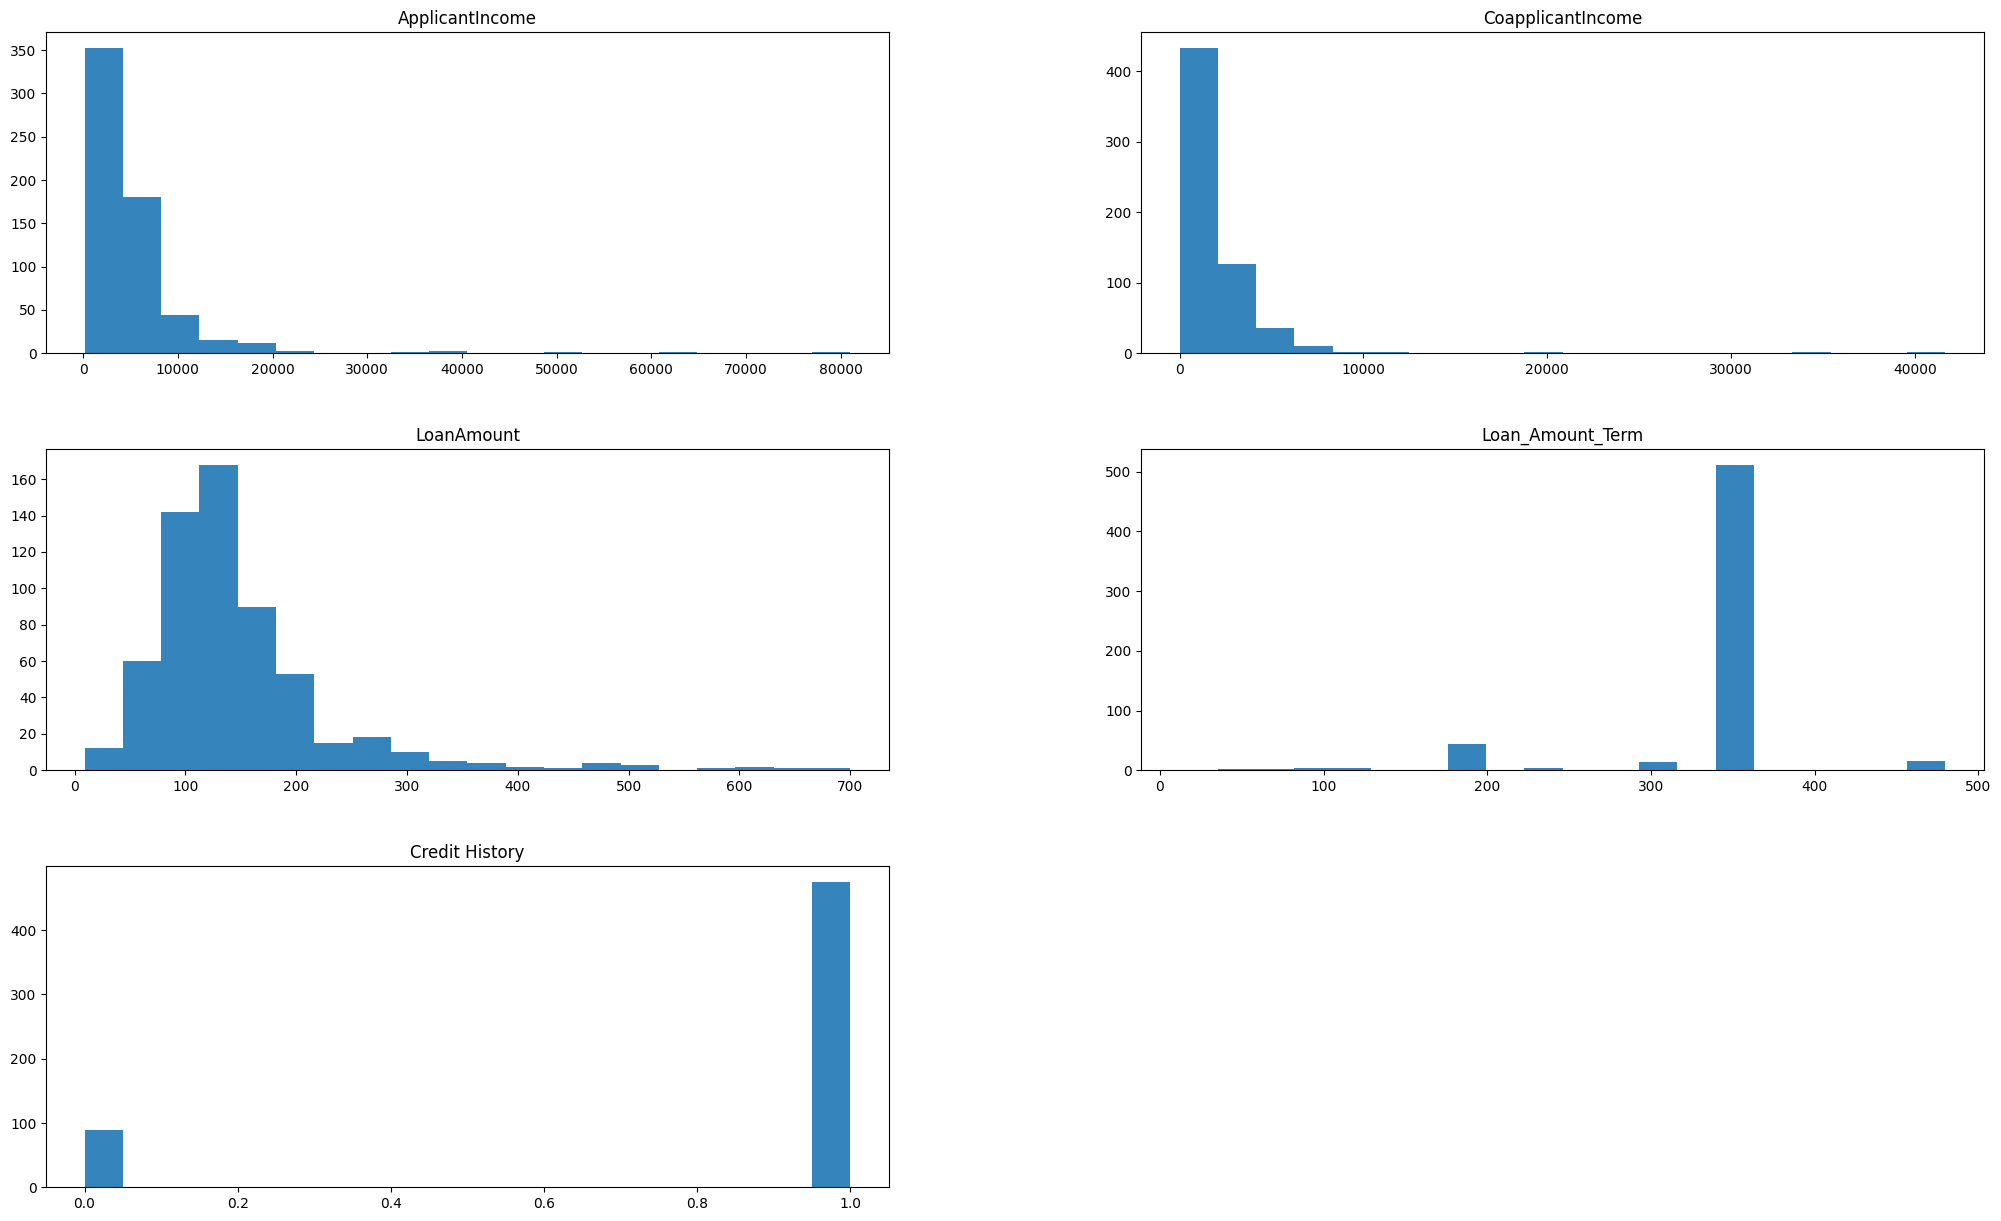

In [6]:
df.hist(bins=20, figsize=(25,15), alpha=0.9, grid=False)

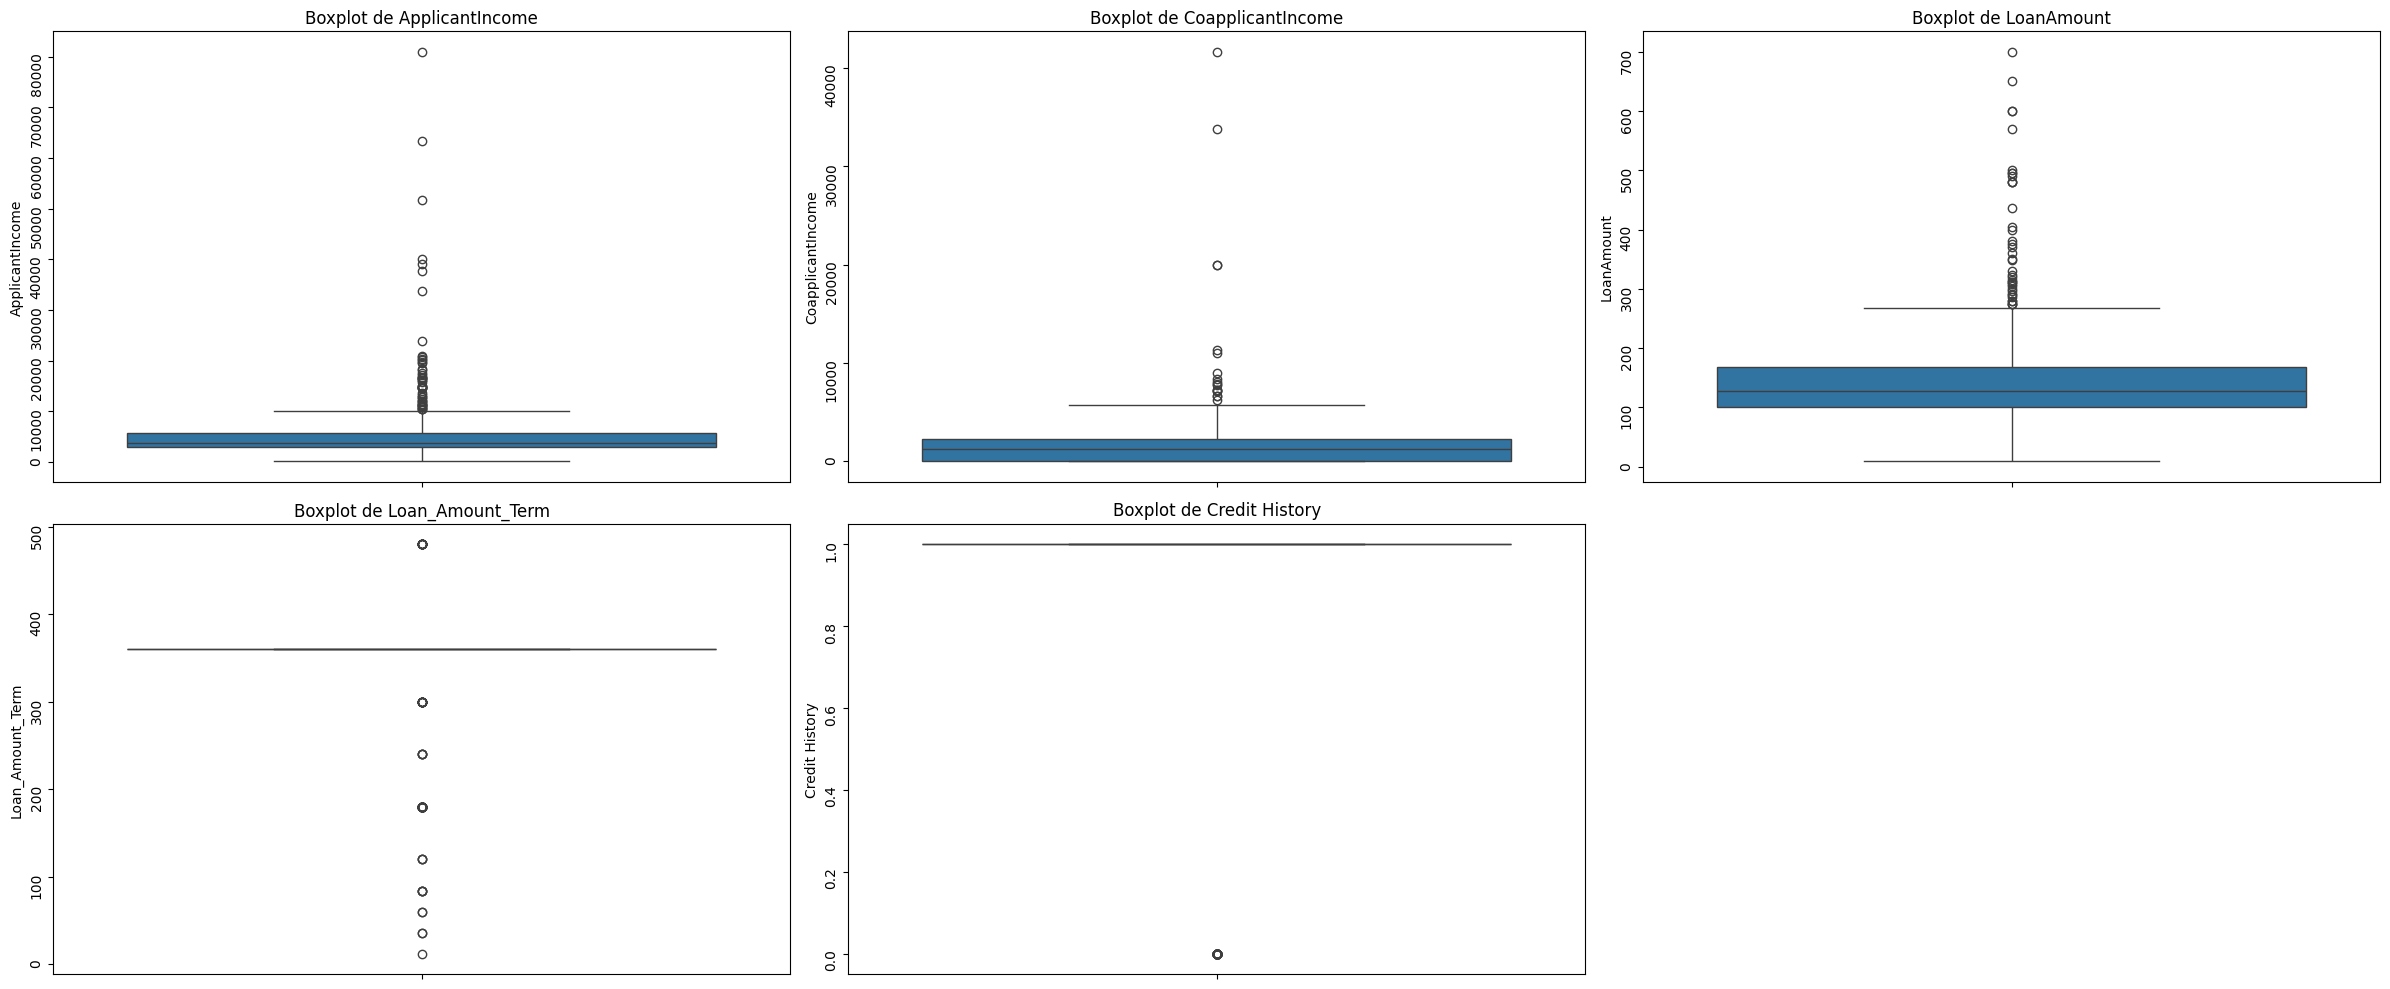

In [7]:
v_num = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 10))
axes_flat = axes.flatten() 

for i, col in enumerate(v_num):
    ax = axes_flat[i]
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'Boxplot de {col}')
    ax.tick_params(axis='y', rotation=90) 

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
df['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

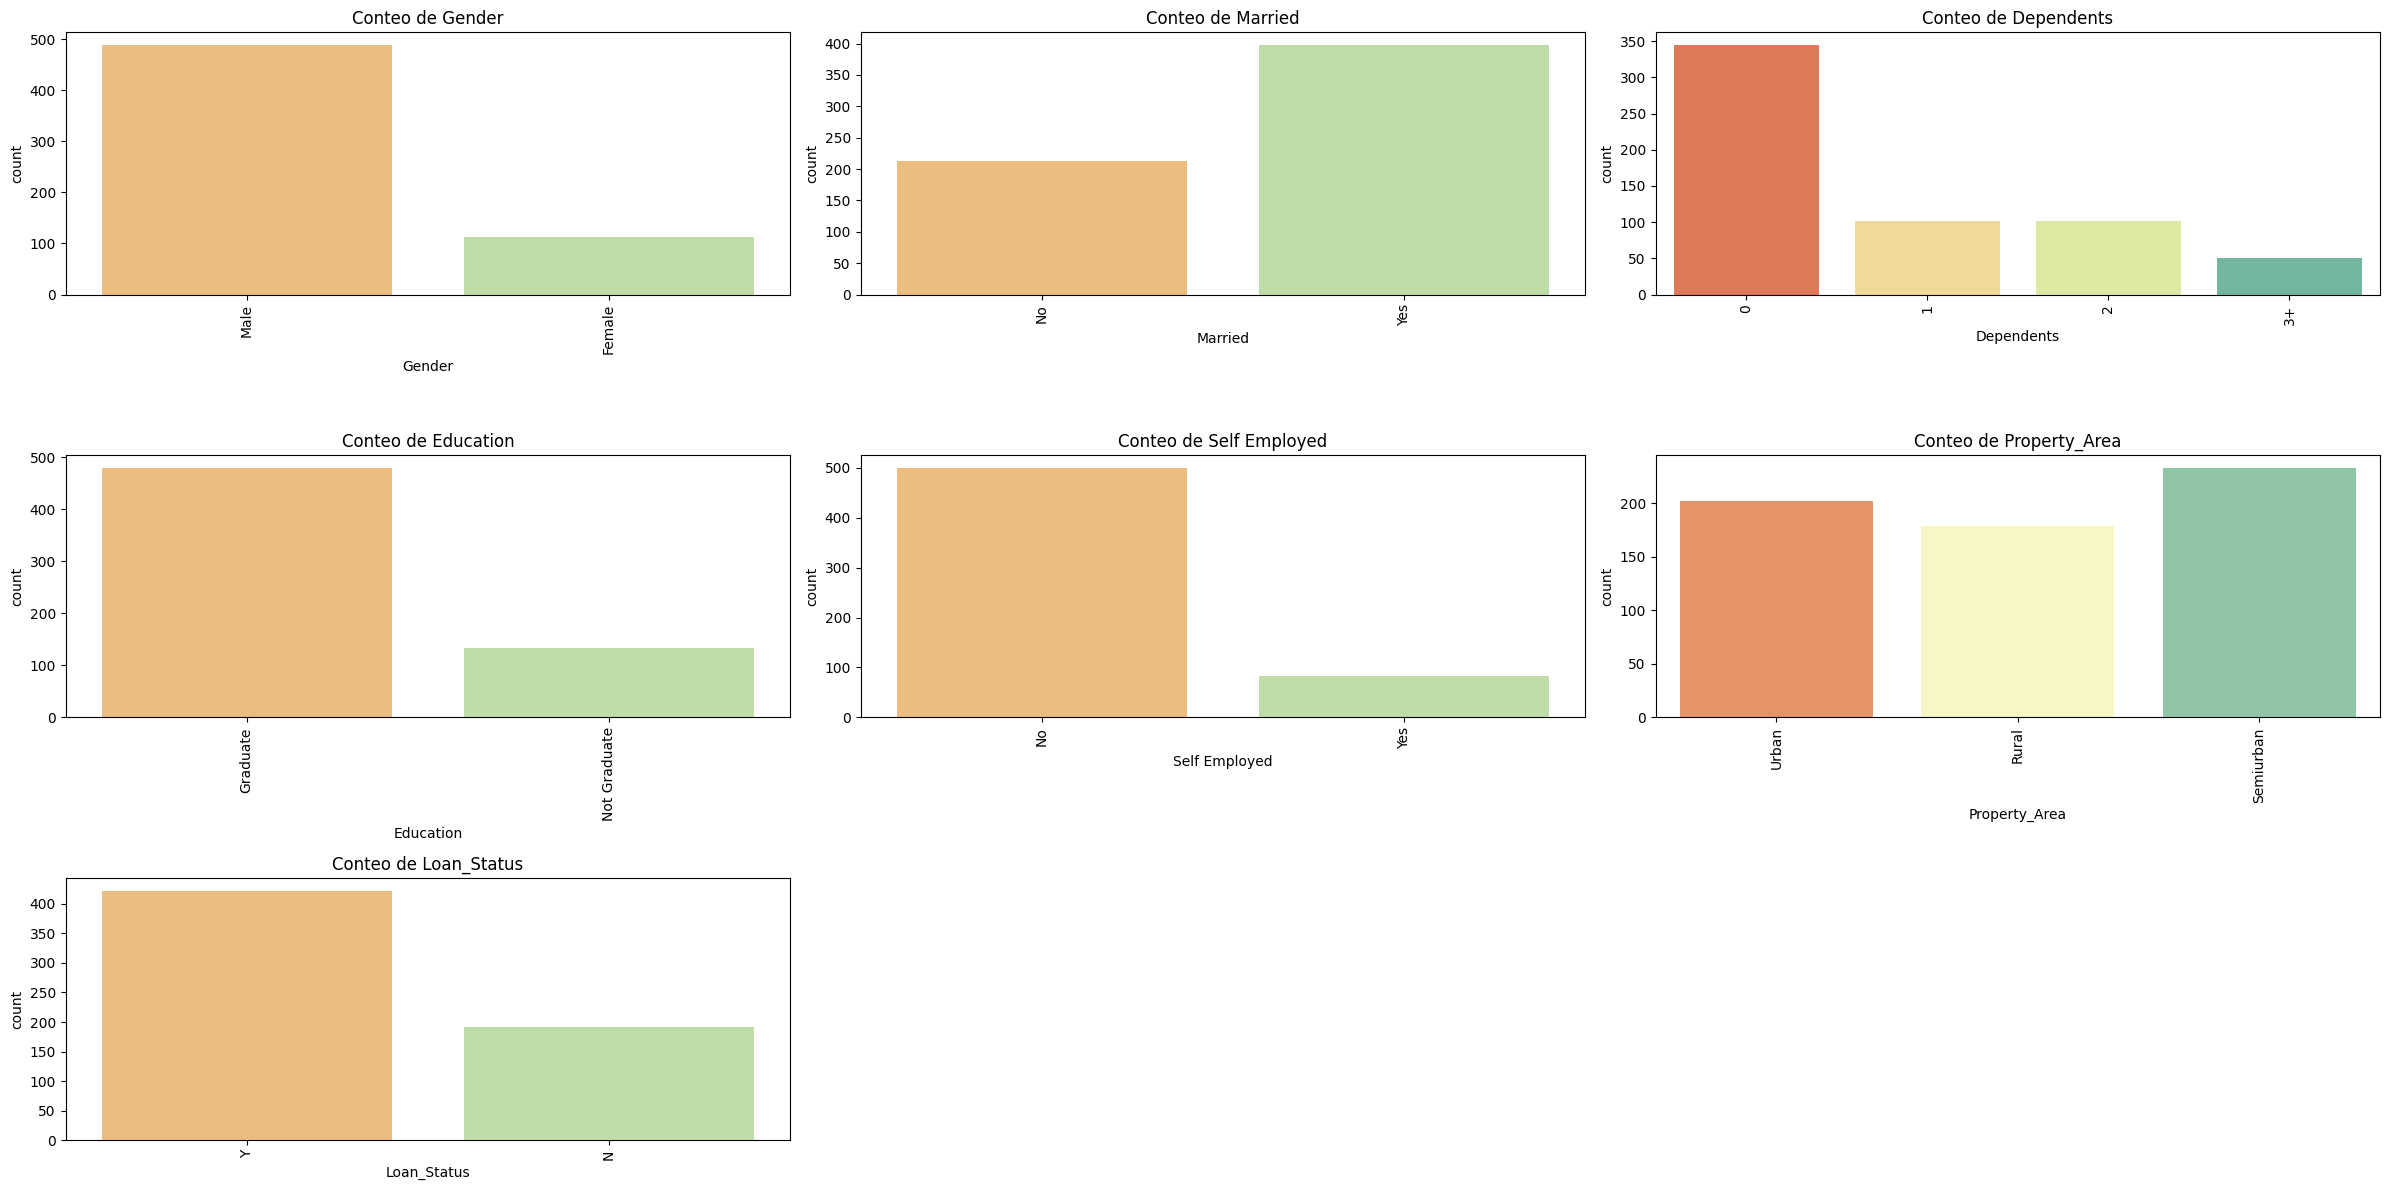

In [9]:
v_cat = df.select_dtypes(include='object').columns.tolist()
v_cat.remove('Loan ID')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24, 12))
axes_flat = axes.flatten() 

for i, col in enumerate(v_cat):
    ax = axes_flat[i]
    sns.countplot(data=df, x=col, ax=ax, palette="Spectral")
    ax.set_title(f'Conteo de {col}')
    ax.tick_params(axis='x', rotation=90) 

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

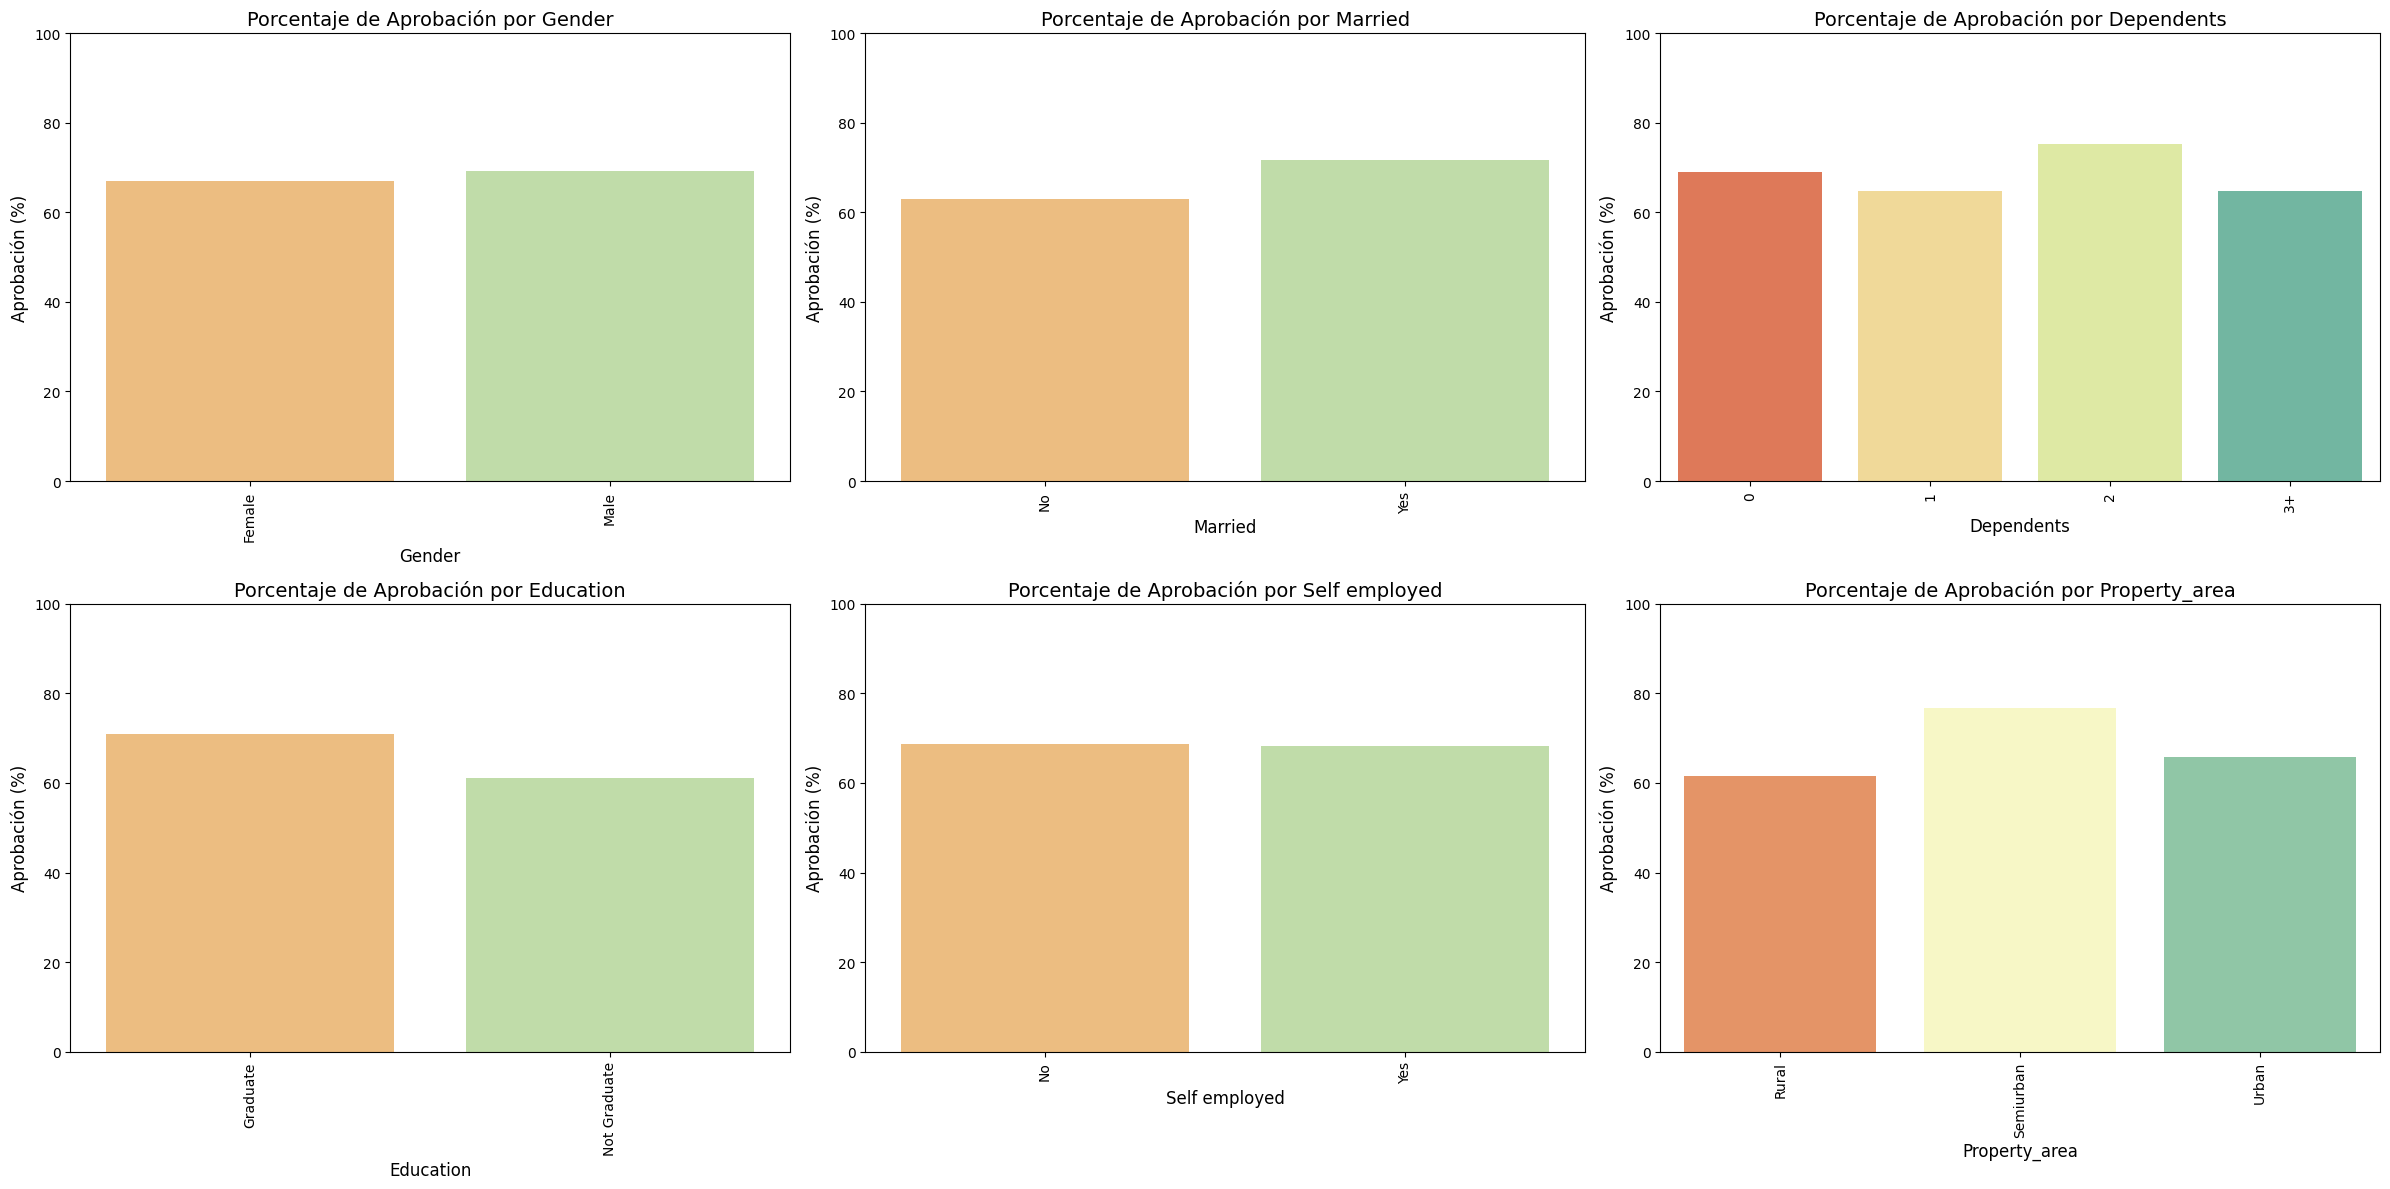

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))
axes_flat = axes.flatten()  

for i, (col, ax) in enumerate(zip(v_cat, axes_flat)):
    status_loan = (
        df.groupby(col)['Loan_Status']
          .apply(lambda x: (x == 'Y').mean() * 100)
          .reset_index(name='pct_aprobacion')
                   )

    sns.barplot(data=status_loan, x=col, y='pct_aprobacion', ax=ax, palette="Spectral")

    ax.set_title(f'Porcentaje de Aprobación por {col.capitalize()}', fontsize=14)
    ax.set_xlabel(col.capitalize(), fontsize=12)
    ax.set_ylabel("Aprobación (%)", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(False)
    ax.set_ylim(0, 100)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

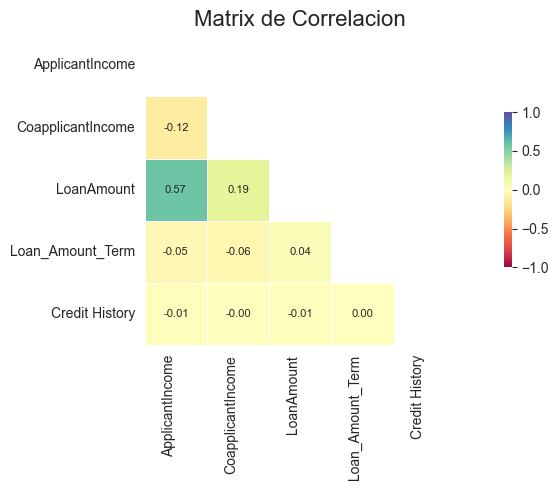

In [11]:
corr = df[v_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 5))
sns.set_style("white")  

sns.heatmap(corr, mask=mask, cmap="Spectral", 
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matrix de Correlacion", fontsize=16)
plt.tight_layout()
plt.show()

Para estudiar la **dependencia estadística entre dos variables categóricas**, construimos una tabla de contingencia y aplicamos el estadístico **Chi‑cuadrado de Pearson**, que mide la discrepancia entre las frecuencias observadas y las que resultan bajo el supuesto de independencia. Sin embargo, como el estadístico depende del tamaño muestral, utilizamos una medida normalizada, el **coeficiente de Cramér**, que ajusta χ² dividiéndolo por el tamaño de muestra y el mínimo número de categorías. El resultado es una medida de fuerza de asociación en el intervalo [0,1], independiente del tamaño de la muestra

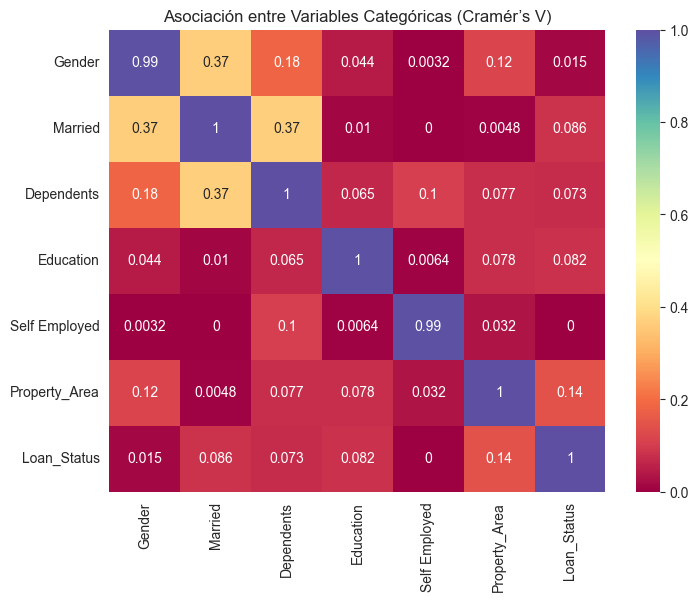

In [12]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape)-1)))

M = pd.DataFrame(index=v_cat, columns=v_cat, dtype=float)

for c1 in v_cat:
    for c2 in v_cat:
        M.loc[c1, c2] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(8,6))
sns.heatmap(M, cmap="Spectral", annot=True, vmin=0, vmax=1)
plt.title("Asociación entre Variables Categóricas (Cramér’s V)")
plt.show()

## **2.2 Pre-Tratamiento**

1. **Limpieza de columnas**: Sin espacios al inicio ni final, remover espacios/- por '_', minúscula.
2. **Limpiar Perímetro**: Solo préstamos con misma naturaleza.
3. **Eliminar variables**: Variables a no incluirse en el modelamiento.
4. **Train y Test**: Definimos los periodos de train, test.
5. **Missing Value**: SimpleImputer.
6. **Outliers**: No se observan valores atípicos.
7. **Variables Categóricas***: Buscar el mejor tratamiento para estas variables.

In [13]:
df.head()

,Loan ID,Gender,Married,Dependents,Education,Self Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
df.groupby('Loan_Amount_Term').size().sort_values(ascending=False)

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
36.0       2
60.0       2
12.0       1
dtype: int64

In [16]:
# -----------------------
# Step 1: Clean column names (strip spaces, lower, replace special chars)
# -----------------------
df.columns = df.columns.str.lower().str.replace(" ", "_").str.strip()     

# -----------------------
# Step 2: Perímetro
# -----------------------
df = df[df['loan_amount_term'] >= 120]

# -----------------------
# Step 3: Drop ID
# -----------------------
df.drop(columns='loan_id', errors="ignore", inplace=True)
v_num = df.select_dtypes(include='number').columns.tolist()
v_cat = df.select_dtypes(include='object').columns.tolist()

# --------------------------
# 4. Sampling: Train/Test
# --------------------------
train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['loan_status']
)

print("\nTrain size:", train.shape[0], "| Aceptación:", round(train['loan_status'][train['loan_status']=='Y'].count()/len(train)*100,2), "%")
print("Test size:", test.shape[0], "| Aceptación:", round(test['loan_status'][test['loan_status']=='Y'].count()/len(test)*100,2), "%")

# -----------------------
# Step 5: Missing Value
# -----------------------
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
train[v_num] = imputer_num.fit_transform(train[v_num])
train[v_cat] = imputer_cat.fit_transform(train[v_cat])

# -----------------------
# Step 6: Outliers
# -----------------------
cols = ['applicantincome', 'coapplicantincome', 'loanamount']

for c in cols:
    train[c] = np.log1p(train[c])

# -----------------------
# Step 7: Variables Categórica
# -----------------------
dep = {'0': 0, 
           '1': 1, 
           '2': 2, 
           '3+': 3}
train['dependents'] = train['dependents'].map(dep)

area = {'Urban': 3,
        'Semiurban': 2,
         'Rural': 0}
train['property_area'] = train['property_area'].map(area)

train['loan_status'] = train['loan_status'].map({'Y': 1, 'N': 0})

dummies = ['education', 'gender', 'self_employed', 'married']
for col in dummies:
    train = pd.get_dummies(train, columns=[col], prefix=f'{col}', drop_first=True)

train.columns = train.columns.str.lower().str.strip()     


Train size: 413 | Aceptación: 69.01 %
Test size: 178 | Aceptación: 69.1 %


## 📌 **3. Feature Engineering***

Buscamos crear variables a raiz del feature actual para poder recoger comportamientos ocultos en el dataset que ayuden a explicar le aprobación del crédito.

1. `total_income`: Suma del ingreso del aplicante + coaplicante
2. `log_total_income`: Transformación logaritmica de los ingresos totales
3. `amount_term`: Relación entre monto y plazo
4. `cuota_ingreso`: Relación entre cuota a pagar e ingreso total
5. `cuota_ingreso_hijo`: relación de la cuota ingreso y la cantidad de dependientes


In [17]:
train['total_income'] = train['applicantincome'] + train['coapplicantincome']

train['log_total_income'] = np.log1p(train['total_income'])

train['amount_term'] = train['loanamount']/train['loan_amount_term']

train["cuota_ingreso"] = (1000*train["loanamount"]/train["loan_amount_term"])/(train["total_income"])

train["cuota_ingreso_hijo"] = (1000*train["loanamount"]/train["loan_amount_term"])/(train["total_income"]/(train["dependents"]+1))

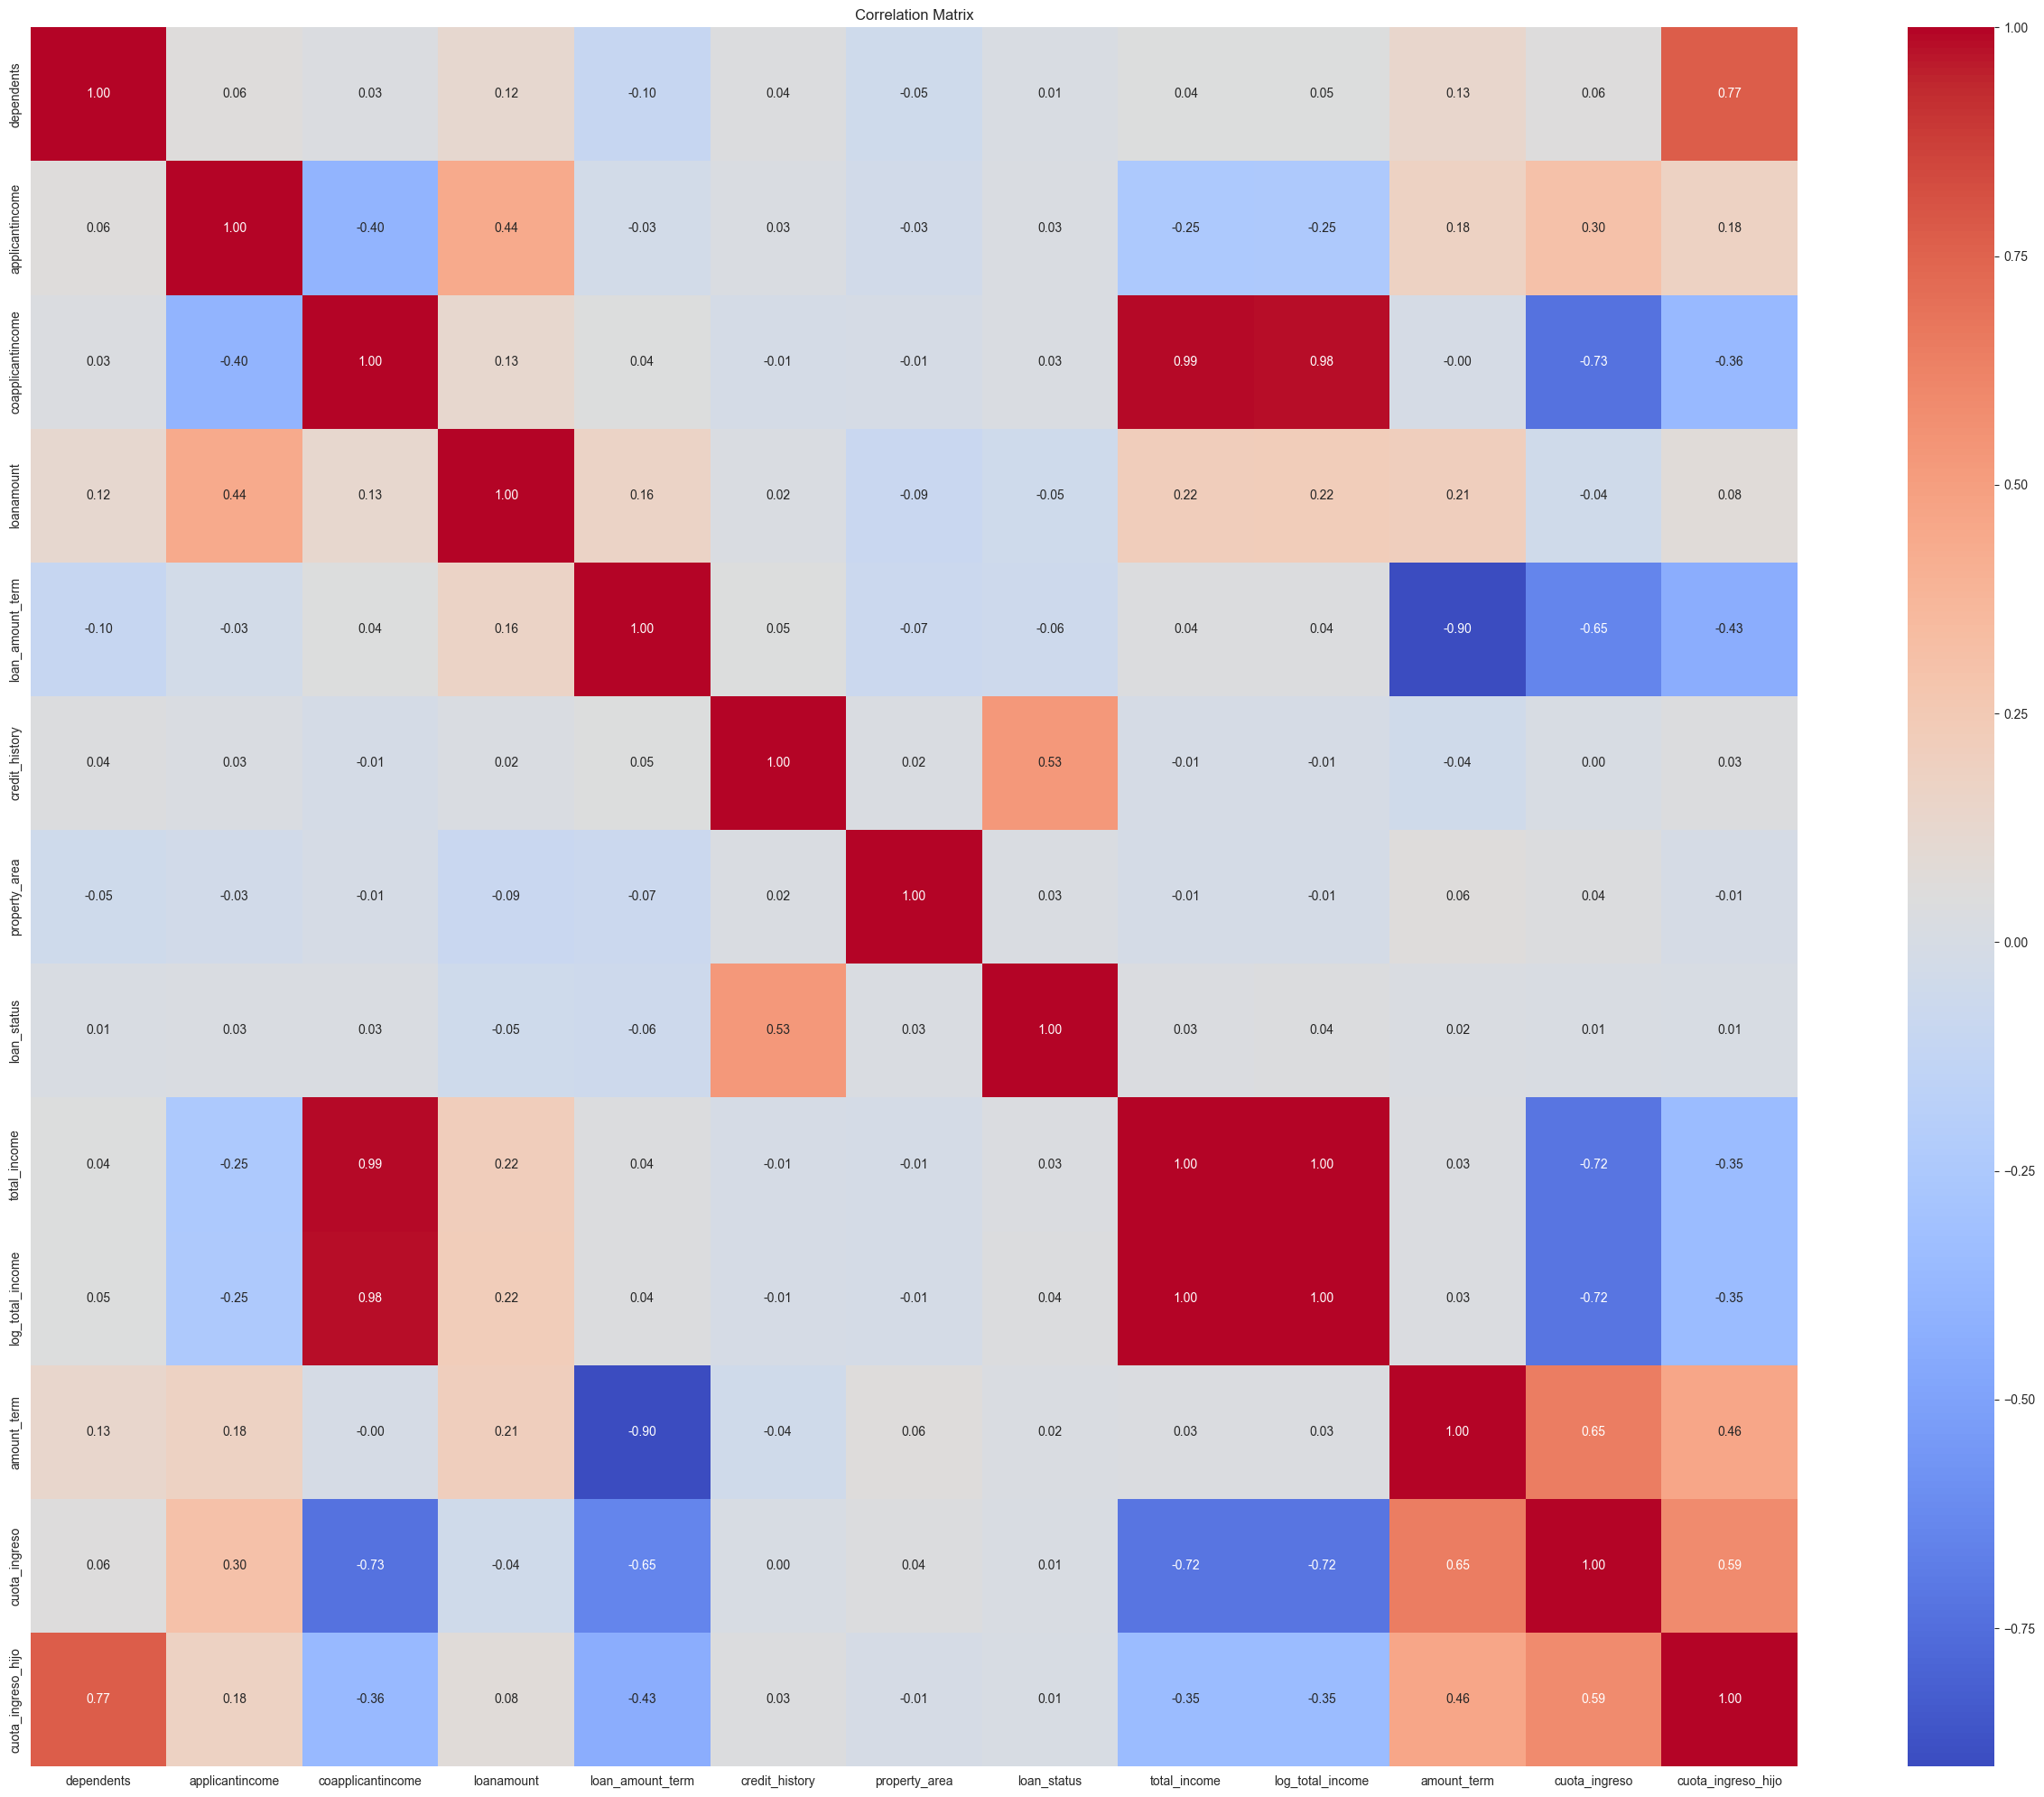

In [18]:
v_num = train.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = train[v_num].corr()

plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [19]:
train.drop(columns=['total_income'], inplace=True, errors='ignore')

## **4. Modelamiento**

In [20]:
X_train, y_train = train.drop(columns=['loan_status']), train['loan_status']

In [58]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# -------------- Functions -----------------
def run_random_search(model, param_grid, X_train, y_train, cv, scoring='f1_macro', n_iter=10, scale=False):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    pipeline = Pipeline(steps)
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    
    search.fit(X_train, y_train)
    return search

In [59]:
# -----------------------------
# ----  LogisticRegression ----
# -----------------------------

print("\n--- Logistic Regression ---")
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
param_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['liblinear', 'saga']
}

search_lr = run_random_search(lr, param_lr, X_train, y_train, cv, n_iter=10, scale=True)

print("Best Hyperparameters Found:")
print(search_lr.best_params_)
print(f"Best Recall in CV: {search_lr.best_score_:.4f}")


--- Logistic Regression ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Hyperparameters Found:
{'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 0.1}
Best Recall in CV: 0.7377


In [60]:
best_lr = search_lr.best_estimator_
best_lr

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1


# **5. Evaluación de Desempeño**

### **Matriz de Confusión: Real vs. Predicho**

Una **matriz de confusión** resume las predicciones frente a la realidad:

| | Predicho Positivo ($Y$) | Predicho Negativo ($N$) |
| :--- | :---: | :---: |
| **Real Positivo ($Y$)** | **TP** (True Positive) | **FN** (False Negative) |
| **Real Negativo ($N$)** | **FP** (False Positive) | **TN** (True Negative) |

### **Significado de los cuadrantes**:

* **TP (Verdadero Positivo):** El modelo predice $Y$ y realmente es $Y$.
* **TN (Verdadero Negativo):** El modelo predice $N$ y realmente es $N$.
* **FP (Falso Positivo):** El modelo predice $Y$ pero era $N$. (**Error grave en banca**: aprobar crédito a quien no debería).
* **FN (Falso Negativo):** El modelo predice $N$ pero era $Y$. (**Error de oportunidad**: rechazar a un buen cliente).

## **4.2 Accuracy** (Exactitud)

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

*Qué porcentaje de predicciones totales son correctas.*

**Problema:** Con clases desbalanceadas puede ser **engañosa**.
- Ejemplo: si el 90% son "buenos", un modelo que predice "todos buenos" tiene 90% accuracy... pero no sirve.


## **4.3 Precision**

$$Precision = \frac{TP}{TP + FP}$$

* De todos los que el modelo dice que son **malos**, ¿cuántos realmente lo son?
* En banca sería: "si predigo que alguien es de alto riesgo, ¿qué tan seguro estoy?"

## **4.4 Recall** (Sensibilidad o TPR)

$$Recall = \frac{TP}{TP + FN}$$

*De todos los **malos reales**, ¿cuántos identifiqué?*

**Muy importante en scoring bancario:**
- **FN = No detectar mal cliente** $\rightarrow$ pérdida financiera.

**Recall alto** = detectas más malos.


## **4.5 False Positive Rate (FPR)**

$$FPR = \frac{FP}{FP + TN}$$

*De todos los **buenos**, ¿a cuántos clasificó como malos?*
* En banca $\rightarrow$ rechazo injustificado de buenos clientes.

## **4.6 Specificity (TNR)**

$$Specificity = \frac{TN}{TN + FP}$$

### Es lo opuesto de FPR:
$$FPR = 1 - Specificity$$

## **4.7 F1-Score**

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

*Balancea **precision** y **recall***
- Útil cuando una clase es más costosa.


## **4.8 Curva ROC**
La curva ROC grafica:

$$TPR = \frac{TP}{TP + FN}$$

vs

$$FPR = \frac{FP}{FP + TN}$$

Para todos los umbrales posibles de decisión ($0 - 1$).


- **Eje Y = TPR**: qué tan rápido detectas a los malos.
- **Eje X = FPR**: qué tanto castigas a los buenos por error.
- **Buen modelo**: sube rápido (TPR) sin aumentar FPR.

## **4.9 Área Bajo la Curva (AUC)**

$$AUC = P(PD_{malos} > PD_{buenos})$$

*La probabilidad de que el modelo asigne **mayor probabilidad de riesgo** a un cliente **malo** que a uno **bueno**.*

**Ejemplos:**
* **AUC = 0.5**: modelo al azar.
* **AUC = 0.7**: decente.
* **AUC = 0.8**: bueno.
* **AUC = 0.9**: muy bueno.

## **4.10 Coeficiente GINI**
Banca casi siempre reporta la GINI.

$$GINI = 2 \cdot AUC - 1$$

**Ejemplo:**
- **AUC = 0.76**
- $GINI = 2(0.76) - 1 = 0.52$

**Interpretación:**
- **GINI = 0**: modelo aleatorio.
- **GINI = 1**: perfecto.

In [ ]:
# 0. Test Data Preprocessing
v_num = df.select_dtypes(include='number').columns.tolist()
v_cat = df.select_dtypes(include='object').columns.tolist()

# 1. Missing: Data Leakage Check - No imputar con la distribución del test
test[v_num] = imputer_num.transform(test[v_num])
test[v_cat] = imputer_cat.transform(test[v_cat])

# 2. Outliers
cols = ['applicantincome', 'coapplicantincome', 'loanamount']

for c in cols:
    test[c] = np.log1p(test[c])

# 3. Variables Categórica
dep = {'0': 0, 
           '1': 1, 
           '2': 2, 
           '3+': 3}
test['dependents'] = test['dependents'].map(dep)

area = {'Urban': 3,
        'Semiurban': 2,
         'Rural': 0}
test['property_area'] = test['property_area'].map(area)
test['loan_status'] = test['loan_status'].map({'Y': 1, 'N': 0})

dummies = ['education', 'gender', 'self_employed', 'married']
for col in dummies:
    test = pd.get_dummies(test, columns=[col], prefix=f'{col}', drop_first=True)

test.columns = test.columns.str.lower().str.strip()     

# 4. New feature
test['total_income'] = test['applicantincome'] + test['coapplicantincome']

test['log_total_income'] = np.log1p(test['total_income'])

test['amount_term'] = test['loanamount']/test['loan_amount_term']

test["cuota_ingreso"] = (1000*test["loanamount"]/test["loan_amount_term"])/(test["total_income"])

test["cuota_ingreso_hijo"] = (1000*test["loanamount"]/test["loan_amount_term"])/(test["total_income"]/(test["dependents"]+1))

# 5. Drop last columns
test.drop(columns=['total_income'], inplace=True, errors='ignore')

# 6. Split X/y del test
X_test,  y_test  = test.drop(columns=['loan_status']),  test['loan_status']

In [62]:
def evaluate_model(model, X_test, y_test, name='Model'):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    print(f"\n📊 Metrics on Test Set ({name}, Threshold = 0.5):")
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print("Average Precision (PR AUC):", round(average_precision_score(y_test, y_proba), 4))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    return y_proba, y_pred

def plot_evaluation(y_test, y_pred, y_proba, model_name='Model'):
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls, precisions)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(15, 4))

    # 1. Confusion Matrix
    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['N', 'Y'],
                yticklabels=['N', 'Y'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted Label') 
    plt.ylabel('True Label')     

    # 2. ROC Curve
    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, label=f'AUC ROC={auc(fpr, tpr):.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()

    # 3. Precision-Recall Curve
    plt.subplot(1, 3, 3)
    plt.plot(recalls, precisions, label=f'AUC PR={pr_auc:.2f}', color='darkorange')
    plt.title(f'{model_name} - Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()

    plt.tight_layout()
    plt.show()


📊 Metrics on Test Set (Logistic Regression, Threshold = 0.5):
Recall: 0.9106
Precision: 0.8175
F1 Score: 0.8615
ROC AUC: 0.7462
Average Precision (PR AUC): 0.8092
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.55      0.62        55
           1       0.82      0.91      0.86       123

    accuracy                           0.80       178
   macro avg       0.77      0.73      0.74       178
weighted avg       0.79      0.80      0.79       178



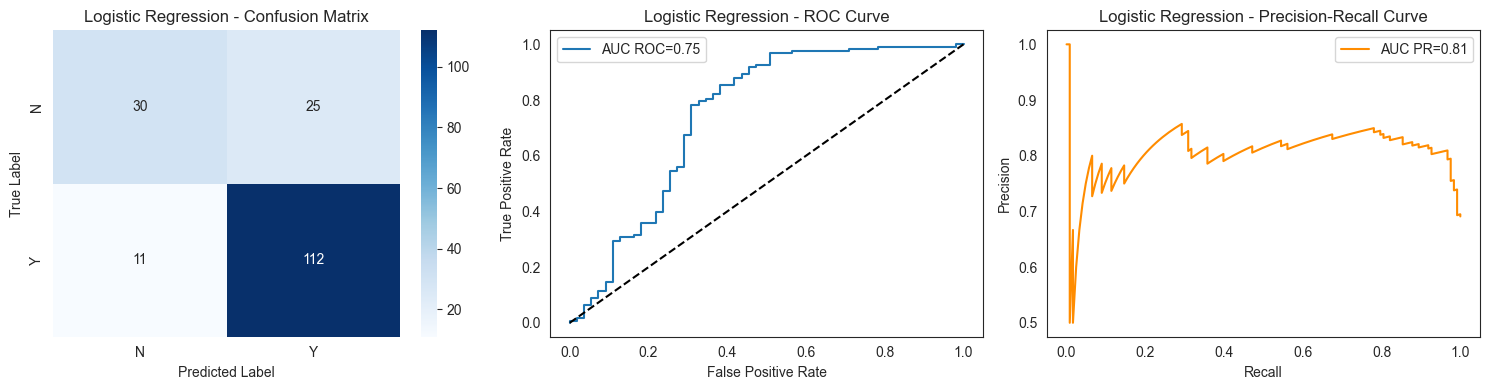

In [64]:
y_proba_lr, y_pred_lr = evaluate_model(best_lr, X_test, y_test, name='Logistic Regression')
plot_evaluation(y_test, y_pred_lr, y_proba_lr, model_name='Logistic Regression')

In [67]:
# UMBRAL OPTIMO
prec, rec, thresholds = precision_recall_curve(y_test, y_proba_lr)
f1 = 2 * (prec * rec) / (prec + rec)
thr_opt = thresholds[f1.argmax()]
print(thr_opt)

0.4373546608097717


## **El Trade-off: Precisión vs. Recall**

En modelos de clasificación (como el scoring bancario), existe un equilibrio inverso entre estas dos métricas:

### **El Dilema del Umbral (Threshold)**
El modelo entrega una **probabilidad** (ej. 0.65). Tú decides dónde cortar para decir "es malo":

1.  **Si bajas el umbral (ej. 0.1):**
    * Te vuelves muy "estricto" y detectas a casi todos los malos (**Recall alto**).
    * **Problema:** Clasificarás a muchos buenos como malos por error (**Precisión baja**).
2.  **Si subes el umbral (ej. 0.9):**
    * Solo etiquetas como "malo" a quien estás segurísimo (**Precisión alta**).
    * **Problema:** Se te escaparán muchos malos que eran menos obvios (**Recall bajo**).

### **¿Por qué hay dos curvas diferentes?**

Aunque parecen similares, miden cosas distintas:

| Característica | **Curva ROC** | **Curva Precision-Recall (PR)** |
| :--- | :--- | :--- |
| **Ejes** | TPR (Recall) vs **FPR** | Precision vs **Recall** |
| **Enfoque** | Evalúa qué tan bien separa el modelo las clases en general. | Se enfoca en el desempeño sobre la **clase positiva** (los "malos"). |
| **Cuándo usarla** | Cuando las clases están **balanceadas**. | Cuando hay **desbalance de clases** (pocos malos, muchos buenos). |

#### ¿Por qué usar PR AUC en banca?
En banca, los "clientes malos" suelen ser muy pocos (ej. 5% de la base). 
* La **ROC** puede ser "optimista" y verse muy bien porque el modelo es bueno identificando a los "buenos" (que son la mayoría).
* La **PR Curve** es más honesta: te muestra qué tan bueno es el modelo realmente para cazar a los "malos" sin equivocarse demasiado.

In [65]:
auc_value = roc_auc_score(y_test, y_proba_lr)
gini = 2 * auc_value - 1
print("GINI:", gini)

GINI: 0.49238728750923877


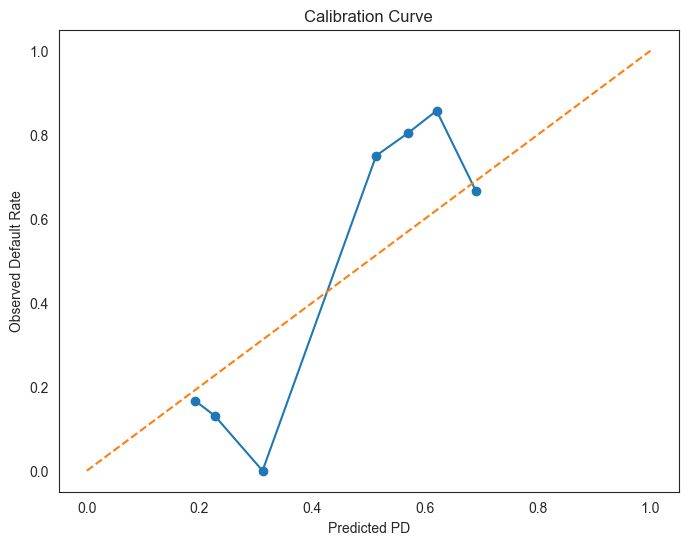

In [56]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba_lr,
    n_bins=15
)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.show()

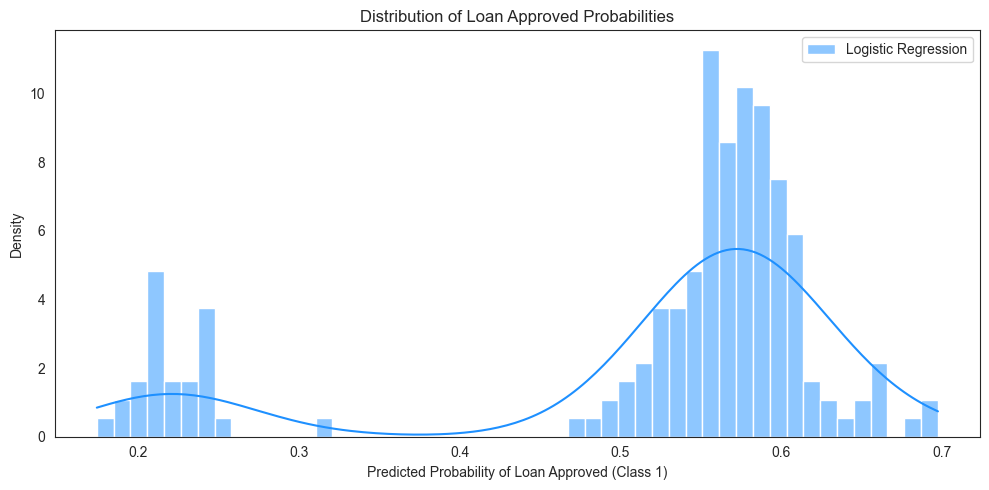

In [52]:
plt.figure(figsize=(10, 5))

sns.histplot(y_proba_lr, label='Logistic Regression', color='dodgerblue', kde=True, stat='density', bins=50)

plt.title('Distribution of Loan Approved Probabilities') 
plt.xlabel('Predicted Probability of Loan Approved (Class 1)') 
plt.ylabel('Density') 
plt.legend()
plt.tight_layout()
plt.show()